# Head metrics on the shared classes: both axes, every stage

Is the head better on the narrow or on the wide axis for the classes both heads predict, and does the wide axis profit more from pretraining?

## Introduction

The thesis tested in parts 2-6 is that synthetic pretraining improves on the model trained on real data only.
Every table therefore contains the **real-only baseline** of the same axis (10 real epochs from the same
initialization) and every comparison is a **paired difference to that baseline**.

The ten pretraining variants differ only in the synthetic data seen before real data (campaign methodology,
`pretraining_campaign_methodology.md`):

| Variant | Synthetic phases | Construction |
| --- | --- | --- |
| P0 single bins | 1 x 10 epochs | ten spectra per axis bin; annotated bins carry their labels, blank bins are known negatives |
| P1 permutations | 1 x 10 epochs | component-token bag (30 per class and per blank bin) packed into mixed spectra |
| P2 joint / staged | 1 x 10 / 2 x 10 epochs | P0 and P1 rows shuffled together / P0 first, then P1 |
| P3 joint / staged | as P2 | P2 + overlap quota (30 extra tokens per class that shares a bin with another class in a training pixel) |
| P4 joint / staged | as P2 | P2 + rare quota (30 extra tokens per class of the least-annotated quarter) |
| P5 joint / staged | as P2 | P2 + both quotas |

Every variant yields three models along one lineage (stages): `pretrained`, `frozen_head` and `unfrozen_head`.
The staged schedules train twice as many synthetic epochs as the joint ones, so schedule and budget are
confounded (methodology, "Pretraining ablation").

### Assumptions

* **Pairing.** Repetition $r$ uses one initialization seed for the baseline and for every variant and stage
  (verified for all 310 models in the campaign-plan verification). The difference between a variant and the
  baseline of the same repetition removes the initialization effect; the five repetitions are the independent
  units. Pixels are not independent units and never enter a test as such.
* **Data.** Every model is evaluated on identical pixels: the same `train`, `test`, `test_extended` and
  `heldout_image` populations as in part 1, decoded once in the shared cache.
* **Objectives.** Synthetic phases: Masserstein (1.0) + BCE (0.2) on complete synthetic targets. Real phases
  (baseline and both fine-tuning stages): Masserstein (1.0) + VPU (0.2) + contractive (2e-3) + InfoNCE (1e-3,
  multilabel-Jaccard negatives, added by mistake and kept because every model used it).
* **Threshold metrics.** Precision, recall and F1 use $\hat Y \ge 0.5$, as in part 1. A head whose
  probabilities never reach 0.5 on real data has F1 = 0 although its ranking may still carry information;
  average precision is threshold free and is the primary head metric.
* **Uncertainty.** With five repetitions the Student-t interval has 4 degrees of freedom
  ($t_{0.975,4} = 2.78$); an interval that excludes zero is a strong statement, one that includes zero is not
  evidence of no effect.

* **Comparable quantities only.** Global $W_1$ is not comparable across axes (different m/z ranges and bins).
  Reconstruction is compared on the 100 Da windows inside 200-900 m/z shared by both axes, the head on the classes
  that are head columns on both axes (`common`), the latent capacity by dimension-free quantities.
* **Axis difference** $s_m(v^{\mathrm{wide}}_r - v^{\mathrm{narrow}}_r)$, paired by variant, stage and repetition
  (identical pixels and initialization seed across axes): positive = the 100-3000 axis is better.
* **Benefit interaction** $\Delta^{\mathrm{wide}}_r - \Delta^{\mathrm{narrow}}_r$: positive = the wide axis gains
  more from pretraining (relative to its own baseline) than the narrow axis.

### Notation

* $b_r$, $v_r$: value of a metric for the baseline and for a variant (at one stage) in repetition $r$.
* $s_m \in \{-1, +1\}$: direction of metric $m$; $-1$ for lower-is-better metrics (Masserstein $W_1$,
  spectral angle, MSE, Hamming loss, window contribution and within-window $W_1$, absolute mass imbalance, ECE,
  Brier score, true-label rank, false-positive rate and lift, losses), $+1$ otherwise.
* **Improvement** $\Delta_r = s_m (v_r - b_r)$: positive is always better than the baseline.
  **Relative improvement** $\Delta_r / |b_r|$.
* Summary over repetitions: mean $\bar\Delta$, SD $s$, interval $\bar\Delta \pm t_{0.975, n-1}\, s / \sqrt{n}$,
  and the numbers of repetitions with $\Delta_r > 0$ (`+k`) and $\Delta_r < 0$ (`-m`).
* Evaluations: `test` (withheld pixels of training images), `test_combined` (test + rare-class extension, the
  main per-class estimate), `heldout_image` (three images never seen; pooled), `heldout_image_per_image` (mean of
  the per-image values; pooled held-out values understate the ranking because annotations are incomplete across
  images, part 1_08).
* $W_1$: exact one-dimensional Wasserstein-1 distance between TIC-normalized input and reconstruction (m/z
  units); $u$: canonical latent code (LayerNorm affine removed).

## Configuration

In [1]:
import logging
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Library modules log INFO to stdout; warnings stay visible, progress messages do not.
logging.disable(logging.INFO)
current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper.analysis.autoencoder.experiments import pretraining_campaign as campaign
from msi_autoencoder_wrapper.analysis.autoencoder.experiments.pretraining_campaign_precompute import (
    load_metadata, load_table, run_command,
)
from msi_autoencoder_wrapper.analysis.precompute.notebook_inputs import load_model_catalog, load_visualization_theme
from msi_autoencoder_wrapper.visualization import pretraining as figures

SETTINGS_PATH = Path("assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml")
ANALYSIS = "axis_prediction_common"
AXIS = None
STAGE = None

settings = campaign.load_settings(SETTINGS_PATH)
theme = load_visualization_theme(settings).with_overrides(figure_dpi=100)
catalog = load_model_catalog(settings)
metadata = load_metadata(settings, ANALYSIS, AXIS, STAGE)
pd.set_option("display.precision", 4)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 80)


def table(name: str) -> pd.DataFrame:
    """Load one canonical table written for this notebook by the precompute."""
    return load_table(settings, ANALYSIS, name, AXIS, STAGE)


def mean_sd(frame: pd.DataFrame, keys: list, columns: list) -> pd.DataFrame:
    """Mean and SD over repetitions of the given columns (presentation helper)."""
    long = frame.melt(id_vars=keys, value_vars=columns, var_name="quantity", value_name="value")
    return long.groupby([*keys, "quantity"]).value.agg(["mean", "std"]).unstack("quantity")


POPULATION_COLORS = {name: figures.population_color(name, theme) for name in figures.POPULATION_ORDER}
print("Analysis:", ANALYSIS, "| axis:", AXIS, "| stage:", STAGE, "| models:", metadata["models"] if isinstance(metadata["models"], int) else len(metadata["models"]))
print("Cache keys:", metadata["cache_keys"])

BASELINE = "baseline"
VARIANTS = list(settings["variants"])
VARIANT_LABELS = {BASELINE: "real-only baseline", **{name: value["label"] for name, value in settings["variants"].items()}}
## The baseline keeps its catalog colour (the dark theme baseline colour is reserved for reference lines)
BASELINE_COLOR = next(value["visualization"]["color"] for value in settings["models"].values()
                      if value.get("select", {}).get("role") == settings["baseline_role"])
VARIANT_COLORS = {BASELINE: BASELINE_COLOR, **{name: value["color"] for name, value in settings["variants"].items()}}
STAGES = list(settings["stages"])
STAGE_LABELS = {"real_only": "real-only baseline", **{name: value["label"] for name, value in settings["stages"].items()}}
KEY_METRICS = settings["comparison"]["key_metrics"]
AXES = list(settings["axes"])
AXIS_LABELS = {name: value["label"] for name, value in settings["axes"].items()}
SHORT = {"masserstein": "W1", "spectral_angle": "spectral angle", "average_precision": "macro AP",
         "micro_average_precision": "micro AP", "f1": "macro F1 at 0.5"}
EVALUATION_NAMES = {**figures.DISPLAY_NAMES, "heldout_image_per_image": "held-out, per image"}


def key_panels(reconstruction=("test", "heldout_image"), prediction=("test_combined", "heldout_image_per_image")):
    """Forest-plot panels of the key metrics: (title, row selector)."""
    panels = []
    for spec in KEY_METRICS:
        for evaluation in (reconstruction if spec["family"] == "reconstruction" else prediction):
            selector = {"family": spec["family"], "metric": spec["metric"], "evaluation": evaluation,
                        "ranking": spec.get("ranking", "none")}
            panels.append((f"{SHORT.get(spec['metric'], spec['metric'])}, {EVALUATION_NAMES.get(evaluation, evaluation)}", selector))
    return panels


def interval(frame, digits=3):
    """'mean [ci_low, ci_high] (+k/-m)' strings of a summary table."""
    form = "{:." + str(digits) + "g}"
    return (frame["mean"].map(form.format) + " [" + frame.ci_low.map(form.format) + ", "
            + frame.ci_high.map(form.format) + "] (+" + frame.positive.astype(int).astype(str) + "/-"
            + frame.negative.astype(int).astype(str) + ")")

from msi_autoencoder_wrapper.analysis.autoencoder.experiments.pretraining_campaign_comparison import summarize

ORDER = [BASELINE, *VARIANTS]

PANELS = [('macro AP, test + ext.', {'metric': 'average_precision', 'evaluation': 'test_combined'}), ('macro AP, held-out', {'metric': 'average_precision', 'evaluation': 'heldout_image'}), ('ROC AUC, held-out', {'metric': 'roc_auc', 'evaluation': 'heldout_image'})]

Analysis: axis_prediction_common | axis: None | stage: None | models: 310
Cache keys: {'plan': 'f34a92a8f6f7833f', 'populations': '513690bdd78a83ce', 'synthetic_reference': '6ba5bc1e0839ba0e', 'inference': '0243c1efb93b9c4c'}


## Producing the tables this notebook reads

### Methodology

#### Implementation

`axis_prediction_common` averages the per-class AP and ROC AUC over the eligible classes of the `common`
class set per model and evaluation (annotation retrieval).

The command below is generated by the precompute entry point itself; if a table is missing, `load_table` raises with the same command.

In [2]:
print(run_command(settings, ANALYSIS))

nohup uv run --extra cu118 python -m msi_autoencoder_wrapper.analysis.precompute --settings /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml --analysis axis_prediction_common > /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/shared_precompute.log 2>&1 &


### Remarks

### Notes

## Absolute values of both axes against their real-only baselines

### Methodology

#### Theoretical

The axis-comparison statistics as levels: for every axis, the value of each model (baseline and every stage),
so that a difference between axes can be read against what each axis reaches.

#### Implementation

`metrics` holds one value per model, metric and evaluation population on both axes.

#### Figure descriptions

        Figure: one panel per axis, metric and evaluation; x = real-only baseline and stages (variants pooled: 50 models
        per stage against 5 baseline models). Tables: rows = baseline and variants, columns = axis | stage; the
        baseline row repeats each axis's baseline value.
        Last figure: the unfrozen-head stage only, split by variant (x = real-only baseline and every variant, five
        repetitions each), because pooling the variants of a stage mixes variants with very different effects.

Colours: in the figures the baseline is grey (its mean is the dashed line) and every other group is green when its
mean is better than the baseline mean and red when it is worse. In the tables every cell is mean +/- SD over the
repetitions; green / red cells are better / worse than the baseline cell of the same column (stronger colour = larger
difference within the column), the black frame marks the three best rows of the column and the grey bold row is the
real-only baseline.

In [3]:
LOWER_IS_BETTER = {'masserstein', 'spectral_angle', 'mse', 'hamming_loss', 'expected_calibration_error', 'brier_score',
                   'within', 'contribution', 'absolute_mass_imbalance', 'bic'}
METRIC_ORDER = ['average_precision', 'micro_average_precision', 'roc_auc', 'micro_roc_auc', 'ap_above_prevalence',
                'precision', 'recall', 'f1', 'micro_precision', 'micro_recall', 'micro_f1', 'micro_prevalence',
                'hamming_loss']
ABS_ORDER = [BASELINE, *VARIANTS]
LABELS_ABS = {**VARIANT_LABELS, **{name: VARIANT_LABELS.get(name, name) for name in ABS_ORDER}}


def better(metric):
    """Direction of a metric: 'lower' or 'higher' is better."""
    return 'lower' if metric in LOWER_IS_BETTER else 'higher'

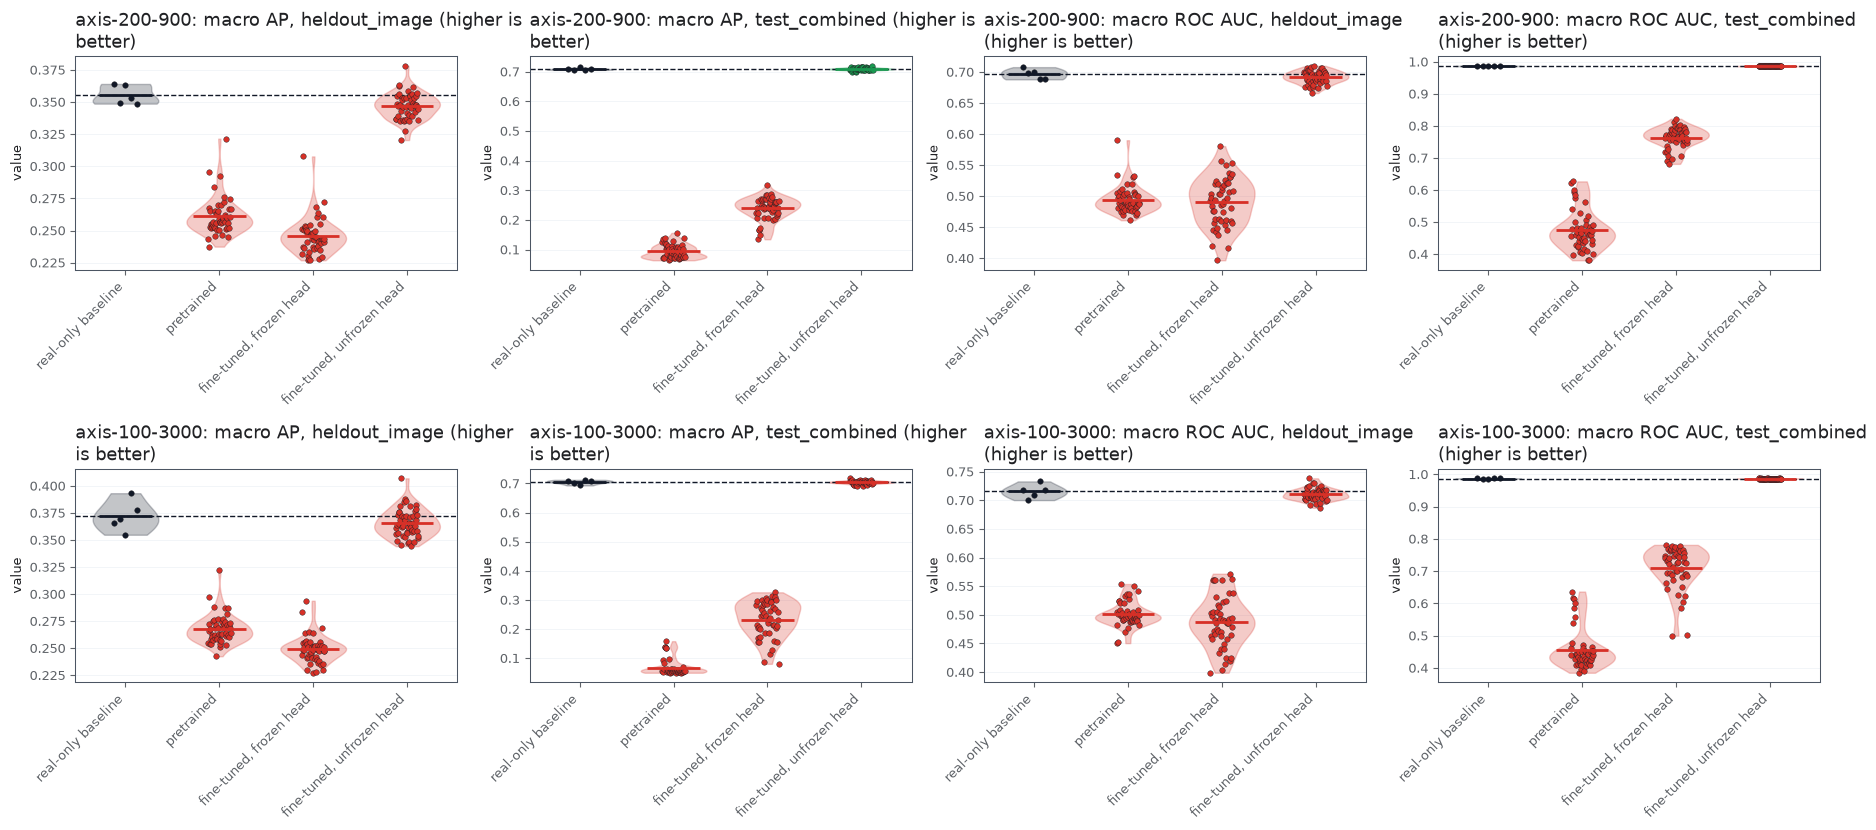

average_precision | heldout_image


column,axis-200-900 | pretrained,axis-200-900 | frozen_head,axis-200-900 | unfrozen_head,axis-100-3000 | pretrained,axis-100-3000 | frozen_head,axis-100-3000 | unfrozen_head
variant,,,,,,
baseline,0.356 +/- 0.007,0.356 +/- 0.007,0.356 +/- 0.007,0.372 +/- 0.014,0.372 +/- 0.014,0.372 +/- 0.014
P0_single,0.262 +/- 0.023,0.253 +/- 0.031,0.343 +/- 0.008,0.271 +/- 0.016,0.256 +/- 0.016,0.357 +/- 0.006
P1_permutation,0.254 +/- 0.001,0.252 +/- 0.002,0.353 +/- 0.012,0.258 +/- 0.004,0.264 +/- 0.017,0.372 +/- 0.005
P2_joint_base,0.260 +/- 0.014,0.239 +/- 0.010,0.343 +/- 0.013,0.271 +/- 0.013,0.244 +/- 0.010,0.374 +/- 0.023
P2_staged_base,0.259 +/- 0.008,0.238 +/- 0.012,0.341 +/- 0.008,0.261 +/- 0.011,0.249 +/- 0.011,0.365 +/- 0.013
P3_joint_overlap,0.259 +/- 0.009,0.244 +/- 0.004,0.348 +/- 0.019,0.278 +/- 0.026,0.250 +/- 0.009,0.374 +/- 0.013
P3_staged_overlap,0.266 +/- 0.016,0.244 +/- 0.006,0.345 +/- 0.009,0.257 +/- 0.005,0.244 +/- 0.011,0.356 +/- 0.008
P4_joint_rare,0.258 +/- 0.009,0.255 +/- 0.013,0.350 +/- 0.005,0.272 +/- 0.005,0.239 +/- 0.008,0.365 +/- 0.014
P4_staged_rare,0.275 +/- 0.027,0.237 +/- 0.006,0.352 +/- 0.008,0.269 +/- 0.013,0.249 +/- 0.007,0.361 +/- 0.009


average_precision | test_combined


column,axis-200-900 | pretrained,axis-200-900 | frozen_head,axis-200-900 | unfrozen_head,axis-100-3000 | pretrained,axis-100-3000 | frozen_head,axis-100-3000 | unfrozen_head
variant,,,,,,
baseline,0.709 +/- 0.003,0.709 +/- 0.003,0.709 +/- 0.003,0.705 +/- 0.007,0.705 +/- 0.007,0.705 +/- 0.007
P0_single,0.096 +/- 0.032,0.232 +/- 0.021,0.709 +/- 0.004,0.071 +/- 0.018,0.234 +/- 0.055,0.710 +/- 0.005
P1_permutation,0.120 +/- 0.012,0.158 +/- 0.016,0.706 +/- 0.005,0.142 +/- 0.010,0.179 +/- 0.025,0.701 +/- 0.007
P2_joint_base,0.099 +/- 0.009,0.260 +/- 0.013,0.706 +/- 0.005,0.065 +/- 0.019,0.272 +/- 0.020,0.702 +/- 0.004
P2_staged_base,0.073 +/- 0.007,0.234 +/- 0.015,0.710 +/- 0.003,0.055 +/- 0.005,0.213 +/- 0.080,0.701 +/- 0.007
P3_joint_overlap,0.105 +/- 0.016,0.287 +/- 0.019,0.710 +/- 0.003,0.057 +/- 0.004,0.285 +/- 0.025,0.707 +/- 0.003
P3_staged_overlap,0.076 +/- 0.006,0.245 +/- 0.024,0.712 +/- 0.005,0.057 +/- 0.005,0.197 +/- 0.050,0.702 +/- 0.007
P4_joint_rare,0.111 +/- 0.029,0.266 +/- 0.020,0.710 +/- 0.004,0.057 +/- 0.003,0.280 +/- 0.030,0.704 +/- 0.005
P4_staged_rare,0.081 +/- 0.016,0.229 +/- 0.018,0.712 +/- 0.001,0.054 +/- 0.003,0.199 +/- 0.057,0.704 +/- 0.005


roc_auc | heldout_image


column,axis-200-900 | pretrained,axis-200-900 | frozen_head,axis-200-900 | unfrozen_head,axis-100-3000 | pretrained,axis-100-3000 | frozen_head,axis-100-3000 | unfrozen_head
variant,,,,,,
baseline,0.697 +/- 0.008,0.697 +/- 0.008,0.697 +/- 0.008,0.716 +/- 0.012,0.716 +/- 0.012,0.716 +/- 0.012
P0_single,0.522 +/- 0.043,0.479 +/- 0.034,0.694 +/- 0.010,0.478 +/- 0.026,0.464 +/- 0.042,0.704 +/- 0.004
P1_permutation,0.493 +/- 0.013,0.464 +/- 0.013,0.693 +/- 0.012,0.526 +/- 0.017,0.532 +/- 0.041,0.715 +/- 0.009
P2_joint_base,0.485 +/- 0.016,0.475 +/- 0.055,0.694 +/- 0.015,0.498 +/- 0.004,0.490 +/- 0.025,0.714 +/- 0.019
P2_staged_base,0.491 +/- 0.011,0.475 +/- 0.035,0.681 +/- 0.012,0.501 +/- 0.025,0.489 +/- 0.035,0.711 +/- 0.012
P3_joint_overlap,0.499 +/- 0.013,0.517 +/- 0.050,0.692 +/- 0.011,0.507 +/- 0.017,0.474 +/- 0.025,0.712 +/- 0.012
P3_staged_overlap,0.488 +/- 0.009,0.496 +/- 0.016,0.688 +/- 0.009,0.506 +/- 0.026,0.486 +/- 0.061,0.708 +/- 0.009
P4_joint_rare,0.485 +/- 0.022,0.502 +/- 0.042,0.695 +/- 0.006,0.492 +/- 0.005,0.459 +/- 0.047,0.710 +/- 0.014
P4_staged_rare,0.512 +/- 0.019,0.480 +/- 0.047,0.695 +/- 0.011,0.506 +/- 0.026,0.481 +/- 0.013,0.709 +/- 0.011


roc_auc | test_combined


column,axis-200-900 | pretrained,axis-200-900 | frozen_head,axis-200-900 | unfrozen_head,axis-100-3000 | pretrained,axis-100-3000 | frozen_head,axis-100-3000 | unfrozen_head
variant,,,,,,
baseline,0.987 +/- 0.000,0.987 +/- 0.000,0.987 +/- 0.000,0.987 +/- 0.001,0.987 +/- 0.001,0.987 +/- 0.001
P0_single,0.499 +/- 0.086,0.752 +/- 0.024,0.987 +/- 0.000,0.512 +/- 0.079,0.732 +/- 0.043,0.987 +/- 0.000
P1_permutation,0.596 +/- 0.019,0.705 +/- 0.020,0.986 +/- 0.000,0.595 +/- 0.023,0.712 +/- 0.047,0.987 +/- 0.000
P2_joint_base,0.468 +/- 0.026,0.775 +/- 0.013,0.986 +/- 0.001,0.433 +/- 0.014,0.747 +/- 0.031,0.986 +/- 0.000
P2_staged_base,0.429 +/- 0.019,0.755 +/- 0.035,0.987 +/- 0.000,0.419 +/- 0.024,0.670 +/- 0.103,0.986 +/- 0.001
P3_joint_overlap,0.471 +/- 0.045,0.800 +/- 0.019,0.987 +/- 0.000,0.417 +/- 0.013,0.761 +/- 0.011,0.987 +/- 0.000
P3_staged_overlap,0.439 +/- 0.013,0.768 +/- 0.016,0.987 +/- 0.000,0.442 +/- 0.032,0.695 +/- 0.042,0.986 +/- 0.001
P4_joint_rare,0.495 +/- 0.046,0.788 +/- 0.018,0.986 +/- 0.000,0.432 +/- 0.020,0.760 +/- 0.014,0.987 +/- 0.000
P4_staged_rare,0.431 +/- 0.060,0.755 +/- 0.030,0.987 +/- 0.000,0.430 +/- 0.014,0.646 +/- 0.051,0.986 +/- 0.000


In [4]:
metrics_abs = table('metrics')
SELECTORS_ABS = [["axis-200-900: macro AP, heldout_image", {"axis": "axis-200-900", "family": "common_classes", "metric": "average_precision", "evaluation": "heldout_image", "ranking": "annotation_retrieval"}, "higher"], ["axis-200-900: macro AP, test_combined", {"axis": "axis-200-900", "family": "common_classes", "metric": "average_precision", "evaluation": "test_combined", "ranking": "annotation_retrieval"}, "higher"], ["axis-200-900: macro ROC AUC, heldout_image", {"axis": "axis-200-900", "family": "common_classes", "metric": "roc_auc", "evaluation": "heldout_image", "ranking": "annotation_retrieval"}, "higher"], ["axis-200-900: macro ROC AUC, test_combined", {"axis": "axis-200-900", "family": "common_classes", "metric": "roc_auc", "evaluation": "test_combined", "ranking": "annotation_retrieval"}, "higher"], ["axis-100-3000: macro AP, heldout_image", {"axis": "axis-100-3000", "family": "common_classes", "metric": "average_precision", "evaluation": "heldout_image", "ranking": "annotation_retrieval"}, "higher"], ["axis-100-3000: macro AP, test_combined", {"axis": "axis-100-3000", "family": "common_classes", "metric": "average_precision", "evaluation": "test_combined", "ranking": "annotation_retrieval"}, "higher"], ["axis-100-3000: macro ROC AUC, heldout_image", {"axis": "axis-100-3000", "family": "common_classes", "metric": "roc_auc", "evaluation": "heldout_image", "ranking": "annotation_retrieval"}, "higher"], ["axis-100-3000: macro ROC AUC, test_combined", {"axis": "axis-100-3000", "family": "common_classes", "metric": "roc_auc", "evaluation": "test_combined", "ranking": "annotation_retrieval"}, "higher"]]
STAGE_ORDER = ['real_only', *STAGES]
figures.metric_panels(metrics_abs, panels=[tuple(item) for item in SELECTORS_ABS], group='stage', order=STAGE_ORDER,
                      labels=STAGE_LABELS, baseline='real_only', columns=4, theme=theme);
plt.show()
for (family, metric, evaluation, ranking), rows in metrics_abs.groupby(['family', 'metric', 'evaluation', 'ranking']):
    base = rows[rows.stage == 'real_only']
    grid = pd.concat([rows[rows.stage != 'real_only'], *[base.assign(stage=stage) for stage in STAGES]])
    grid = grid.assign(column=grid.axis + ' | ' + grid.stage)
    columns = [f'{axis} | {stage}' for axis in AXES for stage in STAGES]
    print(metric, '|', evaluation)
    display(figures.comparison_table(grid, index='variant', columns='column', baseline=BASELINE, order=ABS_ORDER,
                                     column_order=columns, direction={column: better(metric) for column in columns}))

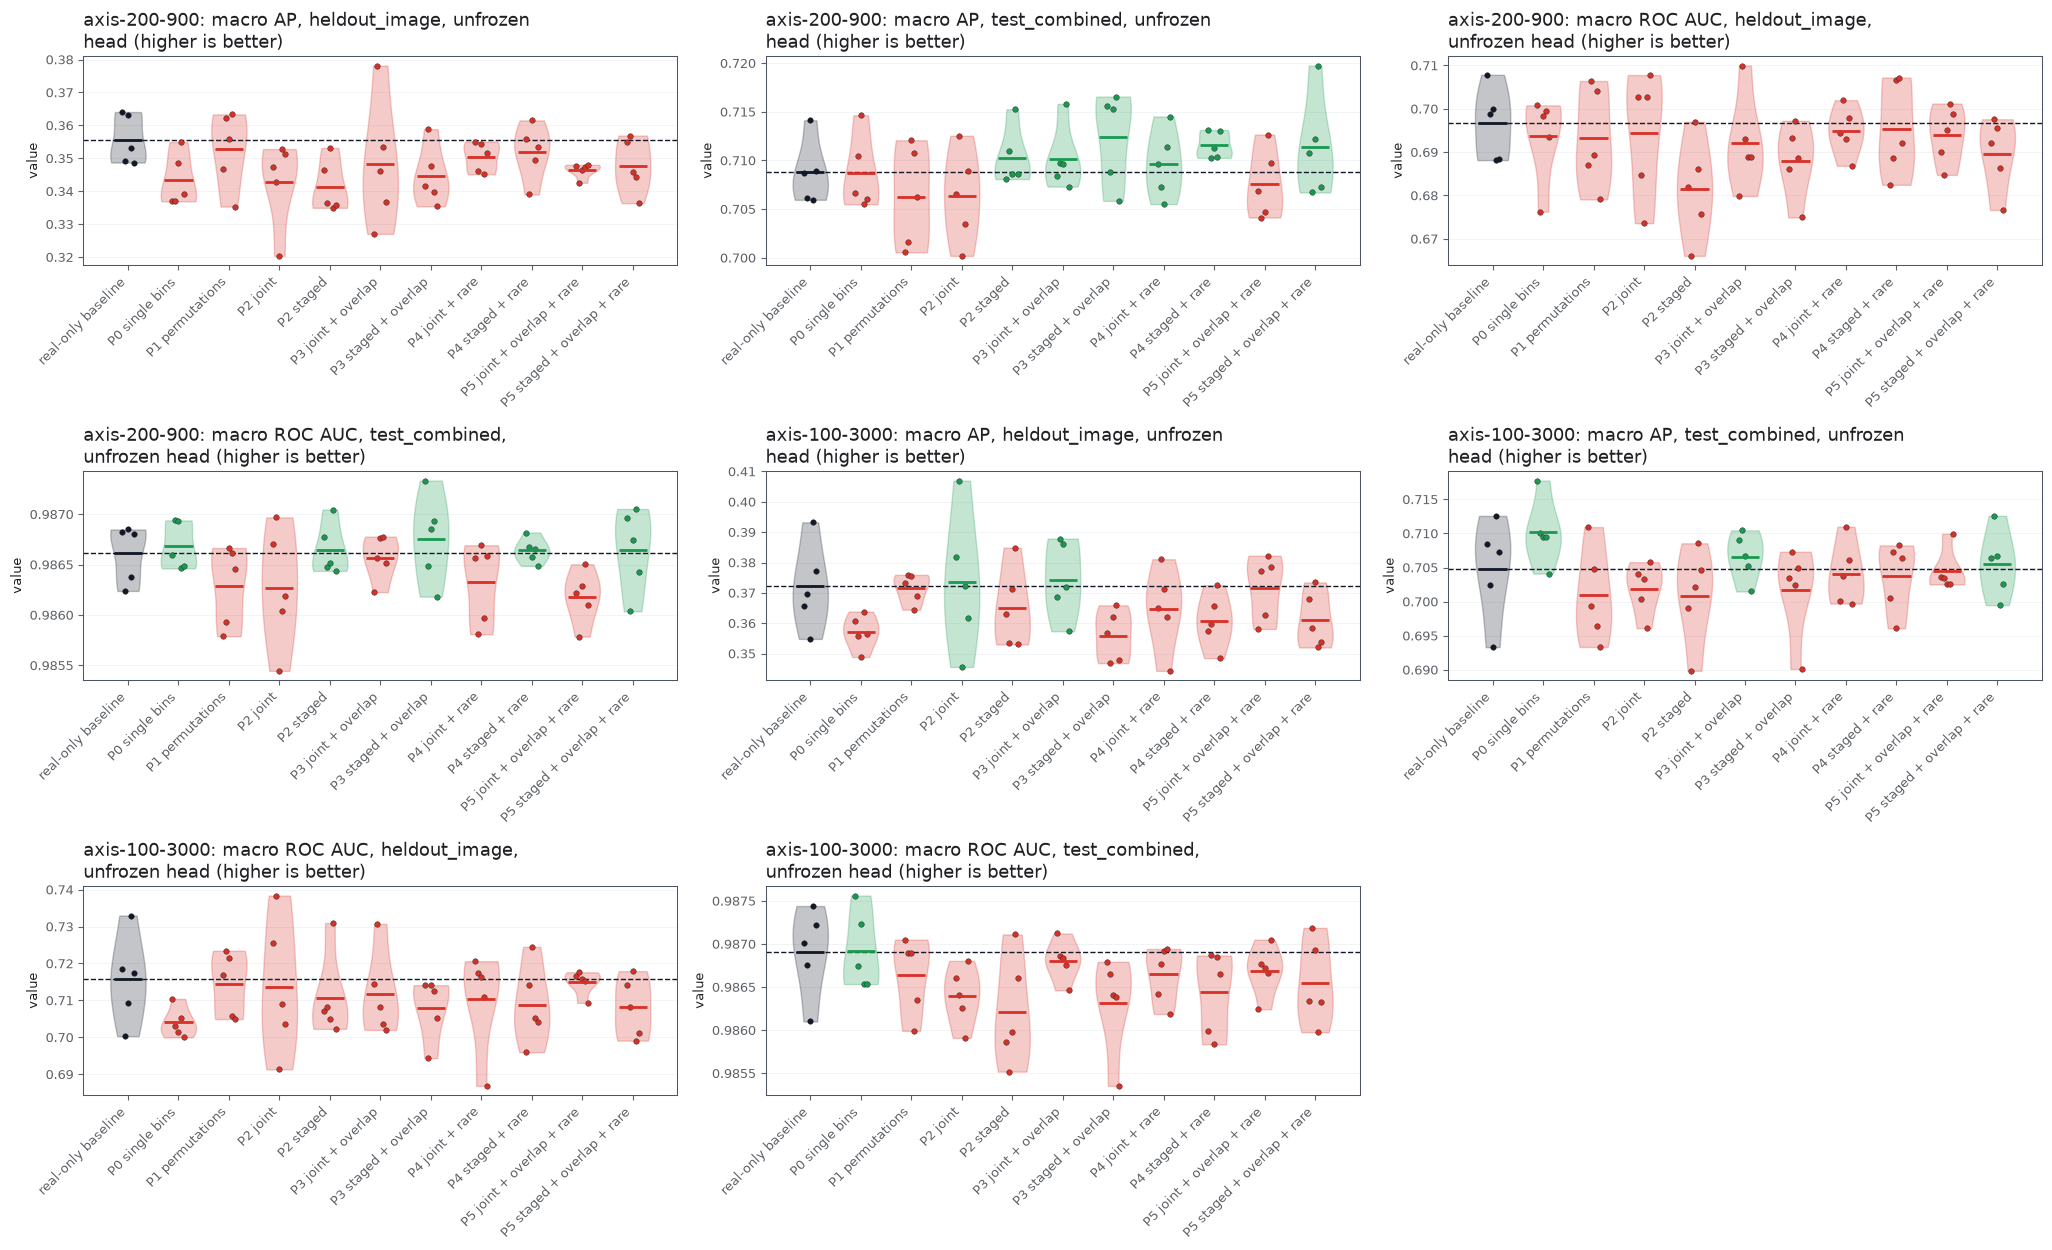

In [5]:
## Unfrozen-head stage per variant (the pooled figure above mixes variants with different effects)
unfrozen = frame_abs[frame_abs.stage.isin(['real_only', 'unfrozen_head'])] if 'frame_abs' in globals() else metrics_abs[metrics_abs.stage.isin(['real_only', 'unfrozen_head'])]
figures.metric_panels(unfrozen, panels=[(f'{label}, unfrozen head', selector, direction) for label, selector, direction in SELECTORS_ABS],
                      group='variant', order=ABS_ORDER, labels=LABELS_ABS, baseline=BASELINE, columns=3, theme=theme);

### Remarks

- axis-200-900: macro AP, heldout_image (by stage): baseline 0.3557; others 0.2456-0.347; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (0.347), worst fine-tuned, frozen head (0.2456).
- axis-200-900: macro AP, heldout_image (unfrozen head, per variant): baseline 0.3557; others 0.3413-0.3527; 0 of 10 better than the baseline; best P1 permutations (0.3527), worst P2 staged (0.3413).
- axis-200-900: macro AP, test_combined (by stage): baseline 0.7088; others 0.09429-0.7094; 1 of 3 better than the baseline; best fine-tuned, unfrozen head (0.7094), worst pretrained (0.09429).
- axis-200-900: macro AP, test_combined (unfrozen head, per variant): baseline 0.7088; others 0.7063-0.7124; 6 of 10 better than the baseline; best P3 staged + overlap (0.7124), worst P1 permutations (0.7063).
- axis-200-900: macro ROC AUC, heldout_image (by stage): baseline 0.6966; others 0.4909-0.6917; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (0.6917), worst fine-tuned, frozen head (0.4909).
- axis-200-900: macro ROC AUC, heldout_image (unfrozen head, per variant): baseline 0.6966; others 0.6814-0.6954; 0 of 10 better than the baseline; best P4 staged + rare (0.6954), worst P2 staged (0.6814).
- axis-200-900: macro ROC AUC, test_combined (by stage): baseline 0.9866; others 0.4743-0.9865; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (0.9865), worst pretrained (0.4743).
- axis-200-900: macro ROC AUC, test_combined (unfrozen head, per variant): baseline 0.9866; others 0.9862-0.9868; 5 of 10 better than the baseline; best P3 staged + overlap (0.9868), worst P5 joint + overlap + rare (0.9862).
- axis-100-3000: macro AP, heldout_image (by stage): baseline 0.3722; others 0.2488-0.3656; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (0.3656), worst fine-tuned, frozen head (0.2488).
- axis-100-3000: macro AP, heldout_image (unfrozen head, per variant): baseline 0.3722; others 0.3559-0.3744; 2 of 10 better than the baseline; best P3 joint + overlap (0.3744), worst P3 staged + overlap (0.3559).
- axis-100-3000: macro AP, test_combined (by stage): baseline 0.7048; others 0.06727-0.704; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (0.704), worst pretrained (0.06727).
- axis-100-3000: macro AP, test_combined (unfrozen head, per variant): baseline 0.7048; others 0.7008-0.7102; 3 of 10 better than the baseline; best P0 single bins (0.7102), worst P2 staged (0.7008).
- axis-100-3000: macro ROC AUC, heldout_image (by stage): baseline 0.7157; others 0.4871-0.7105; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (0.7105), worst fine-tuned, frozen head (0.4871).
- axis-100-3000: macro ROC AUC, heldout_image (unfrozen head, per variant): baseline 0.7157; others 0.704-0.715; 0 of 10 better than the baseline; best P5 joint + overlap + rare (0.715), worst P0 single bins (0.704).
- axis-100-3000: macro ROC AUC, test_combined (by stage): baseline 0.9869; others 0.4552-0.9866; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (0.9866), worst pretrained (0.4552).
- axis-100-3000: macro ROC AUC, test_combined (unfrozen head, per variant): baseline 0.9869; others 0.9862-0.9869; 1 of 10 better than the baseline; best P0 single bins (0.9869), worst P2 staged (0.9862).

### Notes

## Wide minus narrow axis

### Methodology

#### Theoretical

The paired axis difference of every model cell (baseline and every variant and stage).

#### Implementation

`axis_differences` (per repetition) and `axis_difference_summary`.

#### Figure descriptions

Forest plot: rows = baseline and variants, panels = stage x quantity; the baseline row is repeated in
every stage panel as the reference.

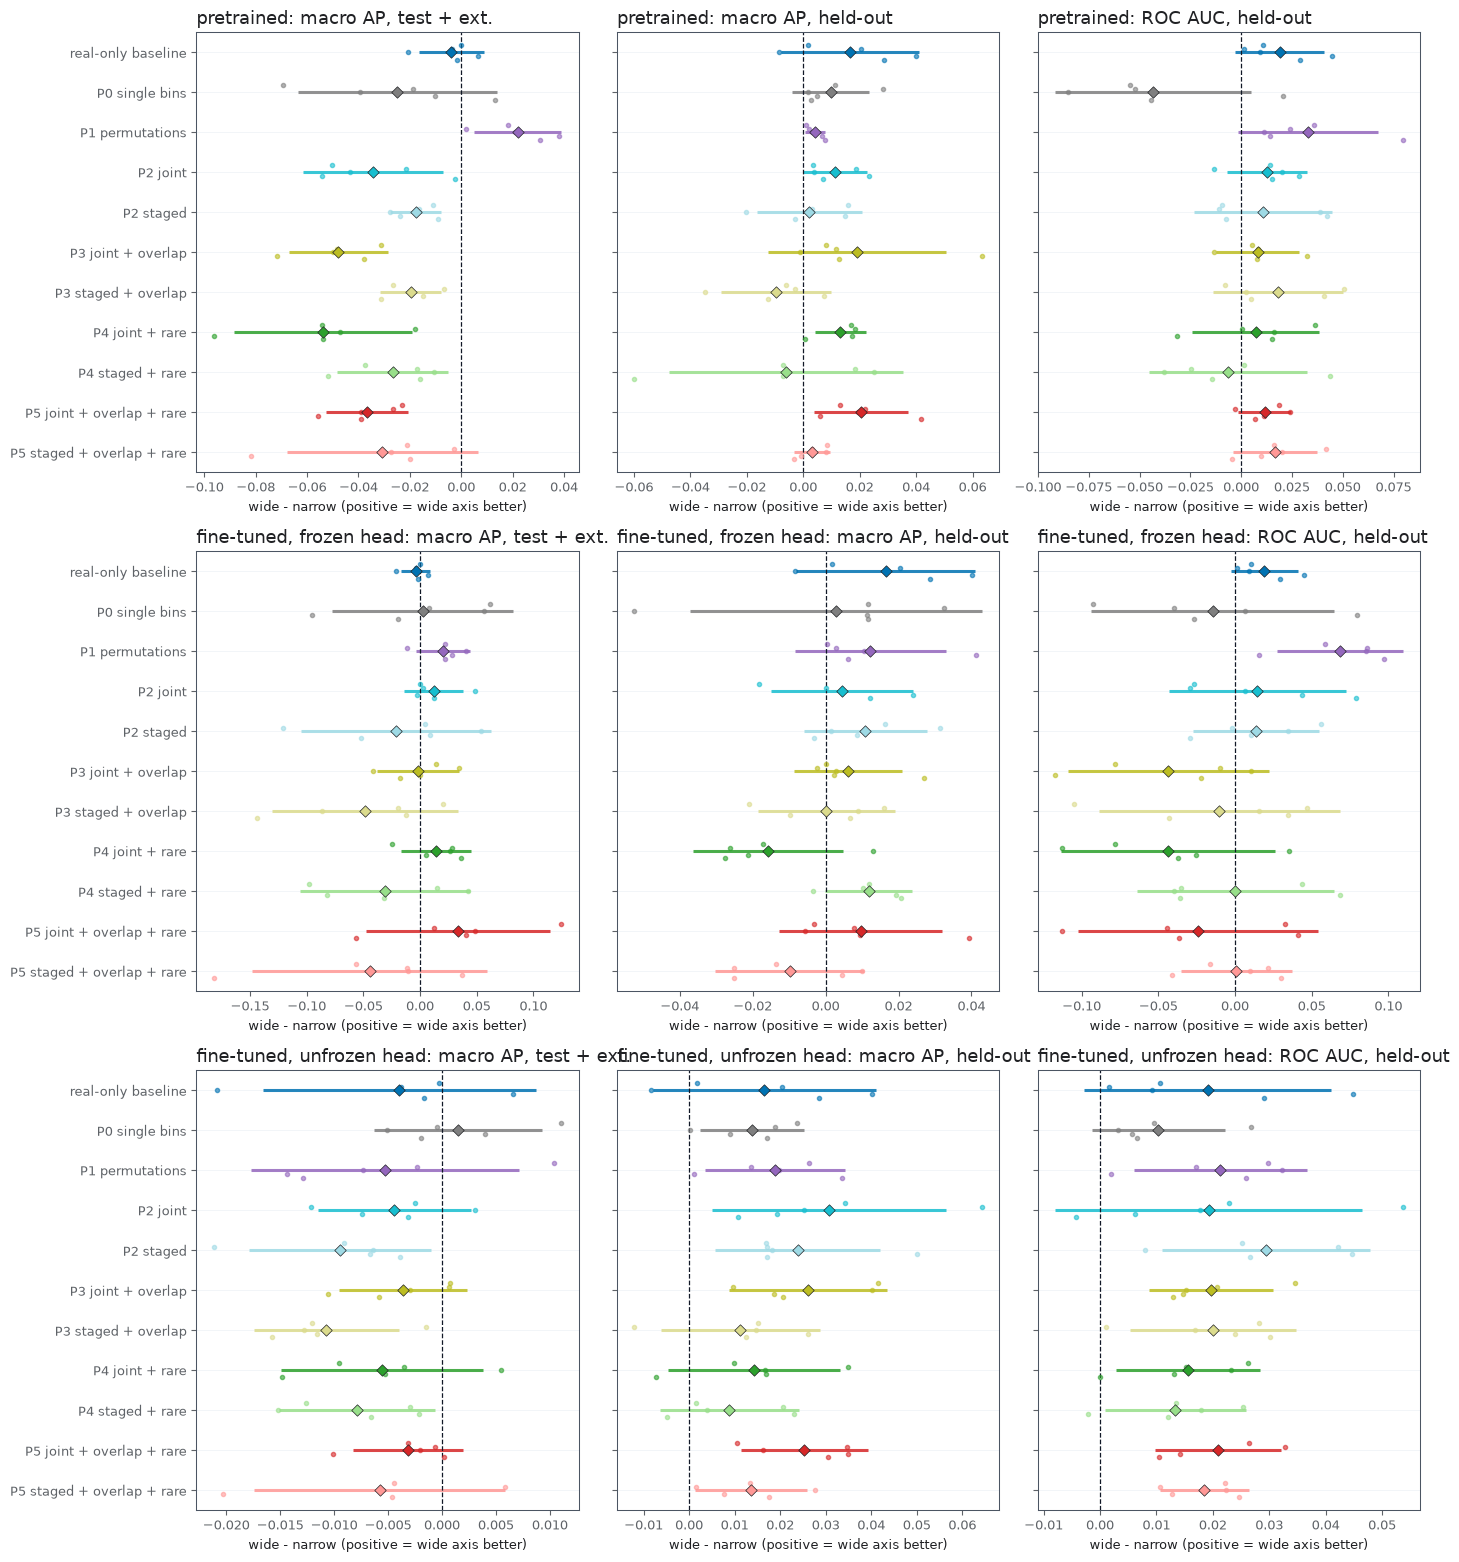

In [6]:
differences = table('axis_difference_summary')
paired = table('axis_differences')
baseline_rows = differences[differences.variant == BASELINE]
expanded = pd.concat([differences[differences.variant != BASELINE], *[baseline_rows.assign(stage=stage) for stage in STAGES]])
baseline_points = paired[paired.variant == BASELINE]
expanded_points = pd.concat([paired[paired.variant != BASELINE], *[baseline_points.assign(stage=stage) for stage in STAGES]])
panels = [(f"{STAGE_LABELS[stage]}: {title}", {**selector, 'stage': stage}) for stage in STAGES for title, selector in PANELS]
figures.improvement_forest(expanded, panels=panels, variants=ORDER, labels=VARIANT_LABELS, colors=VARIANT_COLORS, paired=expanded_points,
                           columns=len(PANELS), xlabel='wide - narrow (positive = wide axis better)', theme=theme);

### Remarks

- Baseline (wide - narrow, sign-adjusted): average_precision held-out 0.0165 [-0.00801, 0.041]; average_precision test+ext -0.00397 [-0.0166, 0.00868]; roc_auc held-out 0.0191 [-0.00277, 0.0409]; roc_auc test+ext 0.000288 [-0.000533, 0.00111].
- pretrained: 4 cells favour the wide axis, 10 the narrow axis, of 40.
- frozen head: 1 cells favour the wide axis, 5 the narrow axis, of 40.
- unfrozen head: 15 cells favour the wide axis, 3 the narrow axis, of 40.

### Notes

## Does the wide axis gain more from pretraining?

### Methodology

#### Theoretical

The benefit interaction compares each axis's improvement over its own baseline. It is the relevant quantity
for the question whether pretraining helps more when the axis is wider (more bins for the same latent
dimension).

#### Implementation

`benefit_interaction` (summary over repetitions).

#### Figure descriptions

Forest plot: rows = variants, panels = stage x quantity.

column,frozen_head | average_precision | heldout_image,frozen_head | average_precision | test_combined,frozen_head | roc_auc | heldout_image,frozen_head | roc_auc | test_combined,pretrained | average_precision | heldout_image,pretrained | average_precision | test_combined,pretrained | roc_auc | heldout_image,pretrained | roc_auc | test_combined,unfrozen_head | average_precision | heldout_image,unfrozen_head | average_precision | test_combined,unfrozen_head | roc_auc | heldout_image,unfrozen_head | roc_auc | test_combined
variant,,,,,,,,,,,,
P0_single,"-0.0136 [-0.0438, 0.0166] (+2/-3)","0.0062 [-0.0826, 0.095] (+3/-2)","-0.0336 [-0.0989, 0.0317] (+1/-4)","-0.0199 [-0.085, 0.0452] (+2/-3)","-0.00678 [-0.0342, 0.0207] (+3/-2)","-0.0209 [-0.0585, 0.0167] (+1/-4)","-0.0623 [-0.0946, -0.0301] (+0/-5)","0.0128 [-0.132, 0.158] (+3/-2)","-0.00279 [-0.0278, 0.0223] (+2/-3)","0.00548 [-0.00416, 0.0151] (+3/-2)","-0.00872 [-0.0387, 0.0213] (+1/-4)","-4.85e-05 [-0.00118, 0.00108] (+2/-3)"
P1_permutation,"-0.0043 [-0.0248, 0.0162] (+2/-3)","0.0245 [-0.00576, 0.0547] (+4/-1)","0.0494 [-0.00785, 0.107] (+4/-1)","0.00747 [-0.0484, 0.0633] (+3/-2)","-0.0124 [-0.0345, 0.00972] (+1/-4)","0.0259 [0.00848, 0.0433] (+5/-0)","0.0138 [-0.0238, 0.0514] (+4/-1)","-0.00137 [-0.0266, 0.0238] (+2/-3)","0.00237 [-0.0314, 0.0362] (+3/-2)","-0.00132 [-0.0195, 0.0168] (+3/-2)","0.00226 [-0.0315, 0.036] (+3/-2)","5.88e-05 [-0.00138, 0.0015] (+3/-2)"
P2_joint_base,"-0.0121 [-0.0296, 0.00542] (+1/-4)","0.0161 [-0.0221, 0.0543] (+4/-1)","-0.00448 [-0.0472, 0.0382] (+1/-4)","-0.0283 [-0.0687, 0.0122] (+1/-4)","-0.00529 [-0.0225, 0.0119] (+2/-3)","-0.0304 [-0.0609, 0.000186] (+0/-5)","-0.0062 [-0.0219, 0.00945] (+2/-3)","-0.0353 [-0.0637, -0.0069] (+0/-5)","0.0142 [-0.0243, 0.0528] (+3/-2)","-0.000458 [-0.0185, 0.0176] (+1/-4)","0.000166 [-0.046, 0.0464] (+3/-2)","-0.000159 [-0.00155, 0.00123] (+2/-3)"
P2_staged_base,"-0.00559 [-0.0352, 0.024] (+3/-2)","-0.0172 [-0.106, 0.0715] (+3/-2)","-0.00515 [-0.0579, 0.0476] (+2/-3)","-0.0851 [-0.173, 0.00268] (+0/-5)","-0.0144 [-0.0363, 0.00757] (+1/-4)","-0.0137 [-0.0258, -0.00162] (+0/-5)","-0.0084 [-0.0389, 0.0221] (+1/-4)","-0.0107 [-0.0442, 0.0228] (+2/-3)","0.00732 [-0.0114, 0.0261] (+3/-2)","-0.00548 [-0.0209, 0.00996] (+1/-4)","0.0103 [-0.0125, 0.033] (+2/-3)","-0.000724 [-0.00157, 0.000126] (+1/-4)"
P3_joint_overlap,"-0.0105 [-0.0348, 0.0138] (+1/-4)","0.00211 [-0.0282, 0.0324] (+2/-3)","-0.0627 [-0.145, 0.0192] (+1/-4)","-0.0391 [-0.0727, -0.0055] (+0/-5)","0.00244 [-0.0165, 0.0214] (+3/-2)","-0.0438 [-0.069, -0.0187] (+0/-5)","-0.0109 [-0.0259, 0.004] (+1/-4)","-0.0547 [-0.113, 0.00334] (+1/-4)","0.00959 [-0.0302, 0.0494] (+2/-3)","0.000384 [-0.0155, 0.0162] (+3/-2)","0.000581 [-0.0281, 0.0293] (+3/-2)","-5.18e-05 [-0.00105, 0.000948] (+2/-3)"
P3_staged_overlap,"-0.0163 [-0.047, 0.0145] (+1/-4)","-0.0444 [-0.122, 0.0335] (+1/-4)","-0.0294 [-0.109, 0.0504] (+2/-3)","-0.0724 [-0.126, -0.0187] (+0/-5)","-0.0263 [-0.0416, -0.011] (+0/-5)","-0.0156 [-0.0333, 0.00196] (+1/-4)","-0.000928 [-0.0372, 0.0354] (+1/-4)","0.00325 [-0.0283, 0.0348] (+3/-2)","-0.00524 [-0.0336, 0.0231] (+2/-3)","-0.00677 [-0.0208, 0.00724] (+2/-3)","0.000935 [-0.0166, 0.0185] (+3/-2)","-0.000726 [-0.00166, 0.000208] (+1/-4)"
P4_joint_rare,"-0.0324 [-0.0748, 0.0101] (+1/-4)","0.0181 [-0.0195, 0.0558] (+3/-2)","-0.0628 [-0.129, 0.00325] (+1/-4)","-0.0286 [-0.0432, -0.0141] (+0/-5)","-0.00336 [-0.0305, 0.0238] (+2/-3)","-0.0499 [-0.0923, -0.0074] (+0/-5)","-0.0118 [-0.06, 0.0364] (+2/-3)","-0.0638 [-0.116, -0.0112] (+0/-5)","-0.00227 [-0.0345, 0.03] (+3/-2)","-0.00158 [-0.022, 0.0188] (+2/-3)","-0.00349 [-0.0341, 0.0271] (+3/-2)","3.42e-05 [-0.000828, 0.000896] (+2/-3)"
P4_staged_rare,"-0.0047 [-0.0201, 0.0107] (+2/-3)","-0.0268 [-0.112, 0.0587] (+2/-3)","-0.0188 [-0.0738, 0.0361] (+2/-3)","-0.109 [-0.198, -0.0204] (+1/-4)","-0.0227 [-0.0806, 0.0351] (+1/-4)","-0.0227 [-0.0551, 0.00969] (+1/-4)","-0.0255 [-0.0507, -0.000321] (+0/-5)","-0.00158 [-0.

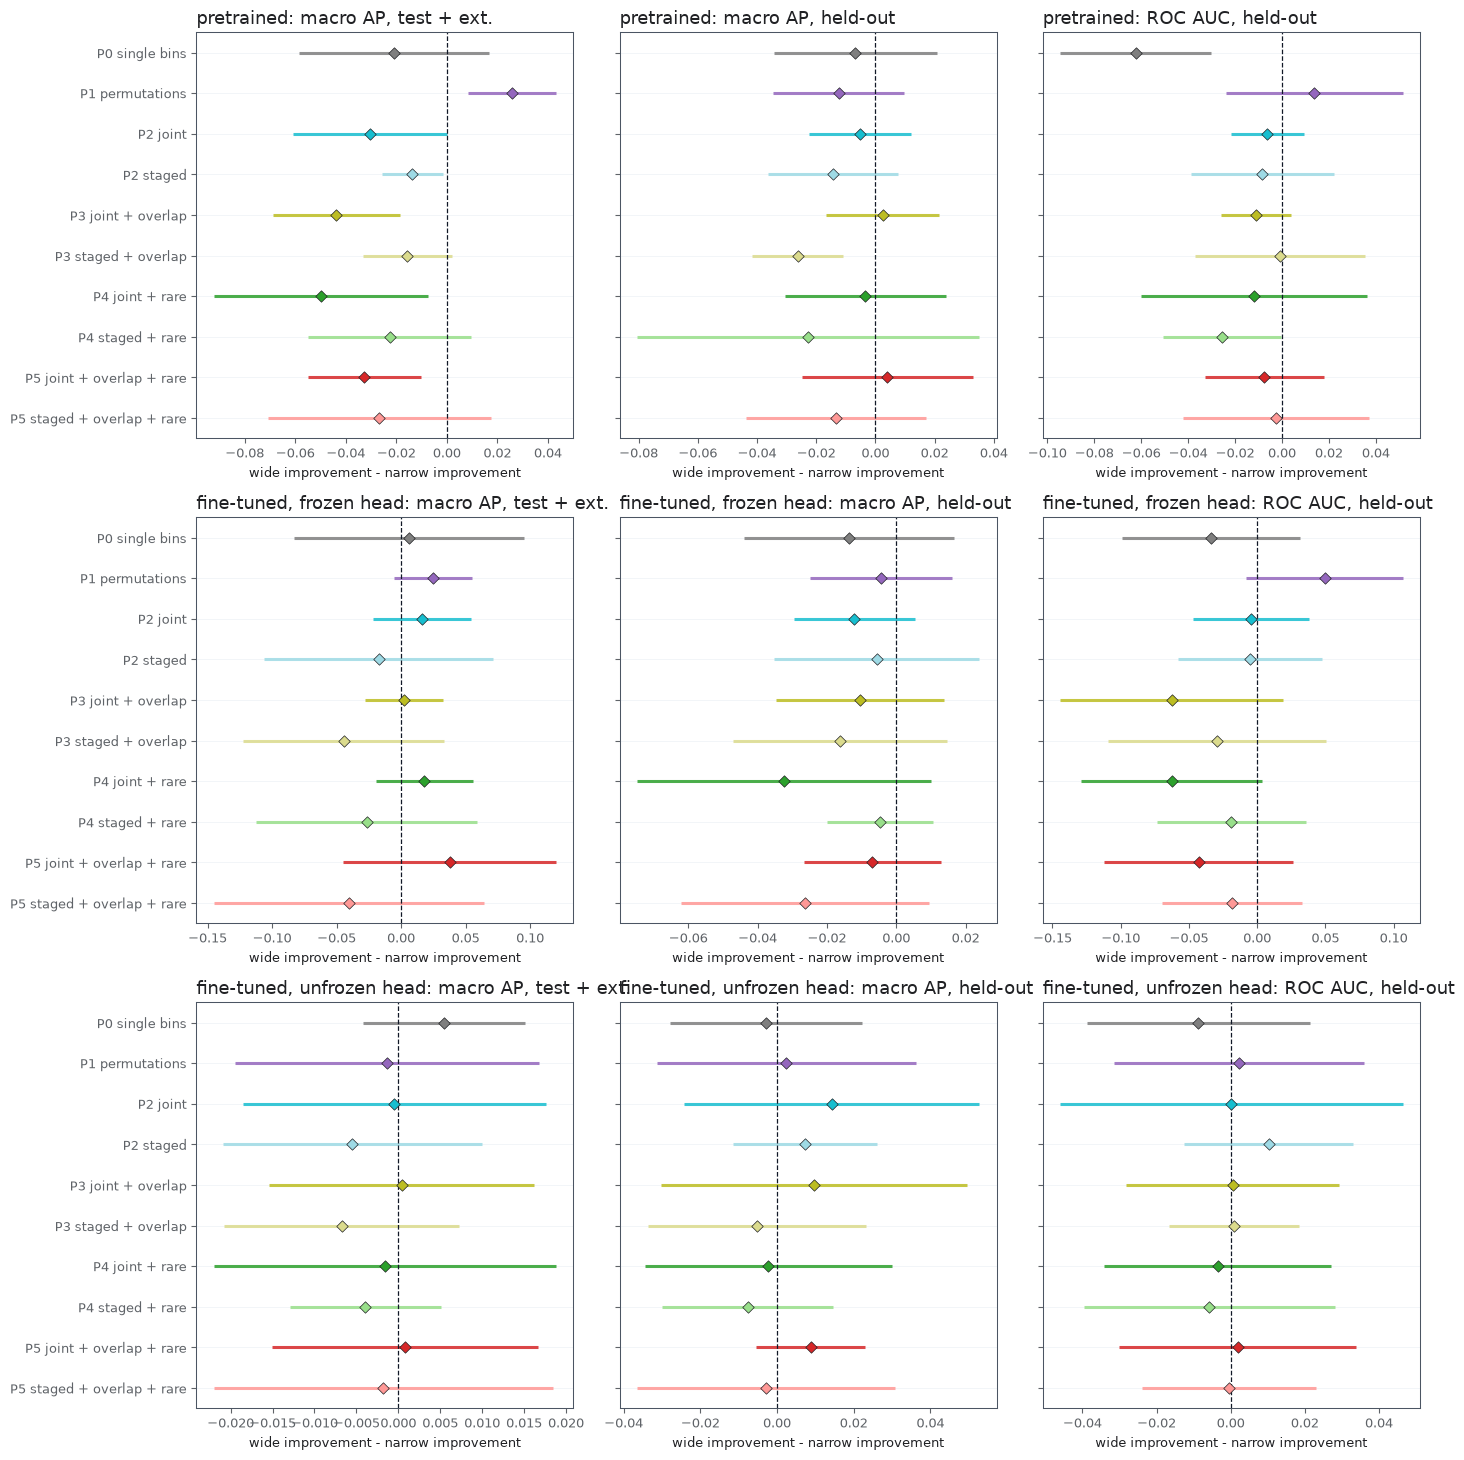

In [7]:
interaction = table('benefit_interaction')
figures.improvement_forest(interaction, panels=panels, variants=VARIANTS, labels=VARIANT_LABELS, colors=VARIANT_COLORS, columns=len(PANELS),
                           xlabel='wide improvement - narrow improvement', theme=theme);
display(interaction.assign(result=interval(interaction), column=interaction.stage + ' | ' + interaction.metric + ' | ' + interaction.evaluation)
        .pivot_table(index='variant', columns='column', values='result', aggfunc='first').reindex(VARIANTS))

### Remarks

- frozen head, average_precision, held-out: wide axis gains more for 0, less for 0 of 10 variants.
- frozen head, average_precision, test+ext: wide axis gains more for 0, less for 0 of 10 variants.
- frozen head, roc_auc, held-out: wide axis gains more for 0, less for 0 of 10 variants.
- frozen head, roc_auc, test+ext: wide axis gains more for 0, less for 5 of 10 variants.
- pretrained, average_precision, held-out: wide axis gains more for 0, less for 1 of 10 variants.
- pretrained, average_precision, test+ext: wide axis gains more for 1, less for 4 of 10 variants.
- pretrained, roc_auc, held-out: wide axis gains more for 0, less for 2 of 10 variants.
- pretrained, roc_auc, test+ext: wide axis gains more for 0, less for 3 of 10 variants.
- unfrozen head, average_precision, held-out: wide axis gains more for 0, less for 0 of 10 variants.
- unfrozen head, average_precision, test+ext: wide axis gains more for 0, less for 0 of 10 variants.
- unfrozen head, roc_auc, held-out: wide axis gains more for 0, less for 0 of 10 variants.
- unfrozen head, roc_auc, test+ext: wide axis gains more for 0, less for 0 of 10 variants.

### Notes

## Results / Summary

### LLM

- **Observed:** on the classes shared by both heads the wide axis is not worse for the baseline, and after unfrozen fine-tuning 15 of 40 cells favour the wide axis; at the unfrozen stage the benefit interaction is inconclusive for every variant.
- **Interpretation:** the wide axis does not cost head quality on the shared classes; pretraining does not change that.

**Absolute levels against the real-only baseline** (means over repetitions; 'better' compares means only, without a test; the intervals are in the improvement sections):

- axis-200-900: macro AP, heldout_image (by stage): baseline 0.3557; others 0.2456-0.347; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (0.347), worst fine-tuned, frozen head (0.2456).
- axis-200-900: macro AP, heldout_image (unfrozen head, per variant): baseline 0.3557; others 0.3413-0.3527; 0 of 10 better than the baseline; best P1 permutations (0.3527), worst P2 staged (0.3413).
- axis-200-900: macro AP, test_combined (by stage): baseline 0.7088; others 0.09429-0.7094; 1 of 3 better than the baseline; best fine-tuned, unfrozen head (0.7094), worst pretrained (0.09429).
- axis-200-900: macro AP, test_combined (unfrozen head, per variant): baseline 0.7088; others 0.7063-0.7124; 6 of 10 better than the baseline; best P3 staged + overlap (0.7124), worst P1 permutations (0.7063).
- axis-200-900: macro ROC AUC, heldout_image (by stage): baseline 0.6966; others 0.4909-0.6917; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (0.6917), worst fine-tuned, frozen head (0.4909).
- axis-200-900: macro ROC AUC, heldout_image (unfrozen head, per variant): baseline 0.6966; others 0.6814-0.6954; 0 of 10 better than the baseline; best P4 staged + rare (0.6954), worst P2 staged (0.6814).
- axis-200-900: macro ROC AUC, test_combined (by stage): baseline 0.9866; others 0.4743-0.9865; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (0.9865), worst pretrained (0.4743).
- axis-200-900: macro ROC AUC, test_combined (unfrozen head, per variant): baseline 0.9866; others 0.9862-0.9868; 5 of 10 better than the baseline; best P3 staged + overlap (0.9868), worst P5 joint + overlap + rare (0.9862).
- axis-100-3000: macro AP, heldout_image (by stage): baseline 0.3722; others 0.2488-0.3656; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (0.3656), worst fine-tuned, frozen head (0.2488).
- axis-100-3000: macro AP, heldout_image (unfrozen head, per variant): baseline 0.3722; others 0.3559-0.3744; 2 of 10 better than the baseline; best P3 joint + overlap (0.3744), worst P3 staged + overlap (0.3559).
- axis-100-3000: macro AP, test_combined (by stage): baseline 0.7048; others 0.06727-0.704; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (0.704), worst pretrained (0.06727).
- axis-100-3000: macro AP, test_combined (unfrozen head, per variant): baseline 0.7048; others 0.7008-0.7102; 3 of 10 better than the baseline; best P0 single bins (0.7102), worst P2 staged (0.7008).
- axis-100-3000: macro ROC AUC, heldout_image (by stage): baseline 0.7157; others 0.4871-0.7105; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (0.7105), worst fine-tuned, frozen head (0.4871).
- axis-100-3000: macro ROC AUC, heldout_image (unfrozen head, per variant): baseline 0.7157; others 0.704-0.715; 0 of 10 better than the baseline; best P5 joint + overlap + rare (0.715), worst P0 single bins (0.704).
- axis-100-3000: macro ROC AUC, test_combined (by stage): baseline 0.9869; others 0.4552-0.9866; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (0.9866), worst pretrained (0.4552).
- axis-100-3000: macro ROC AUC, test_combined (unfrozen head, per variant): baseline 0.9869; others 0.9862-0.9869; 1 of 10 better than the baseline; best P0 single bins (0.9869), worst P2 staged (0.9862).

### Person